<a href="https://colab.research.google.com/github/Clover130/EMSC2010-W8-P1/blob/main/EMSC2010_W8_P1_NB3_u8229609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Question: In what year will the women's Olympic 100 m champion finish faster than the men's Olympic 100 m champion?

Import libraries

In [5]:
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 8.6 MB/s eta 0:00:00


In [6]:
import numpy as np #for working with numerical arrays
import matplotlib.pyplot as plt #for plotting
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes

Input women's historical data where:
* ```W_year```: year of the women's Olympic final
* ```W_time```: time of the winner (in seconds)

In [2]:
W_year = np.array([1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
W_time = np.array([12.2,11.9,11.5,11.9,11.5,11.5,11,11.4,11.08,11.07,11.08,11.06,10.97,10.54,10.82,10.94,10.75,10.93,10.78,10.75,10.71,10.61,10.72])

Input men's historical data where:
* ```M_year```: year of the men's Olympic final
* ```M_time```: time of the winner (in seconds)

In [3]:
M_year = np.array([1900,1904,1908,1912,1920,1924,1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
M_time = np.array([11,11,10.8,10.8,10.8,10.6,10.8,10.3,10.3,10.3,10.4,10.5,10.5,10,9.95,10.14,10.06,10.25,9.99,9.92,9.96,9.84,9.87,9.85,9.69,9.63,9.81,9.8,9.79])

Visualize the historical data.

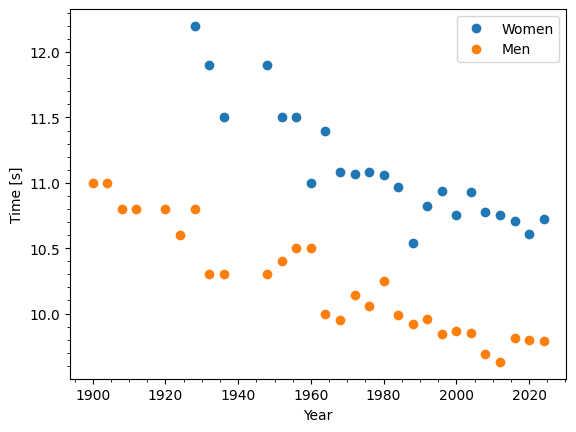

In [4]:
plt.plot(W_year,W_time,'o',label = 'Women')
plt.plot(M_year,M_time,'o',label = 'Men')
plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.legend()
plt.minorticks_on()
plt.show()

To simplify the problem, you can assume that both the women's and men's times follow a straight-line with respect to year.

In [37]:
data = pd.DataFrame({"x": W_year, "y": W_time}) #put the data into a dataframe with variable names "x" and "y".
model = bmb.Model("y ~ x", data) #setup the first-order polynomial model
idata = model.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sample the posteriors

dataM = pd.DataFrame({"x": M_year, "y": M_time}) #put the data into a dataframe with variable names "x" and "y".
modelM = bmb.Model("y ~ x", dataM) #setup the first-order polynomial model
idataM = modelM.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sample the posteriors

/tmp/ipykernel_59563/1005290981.py:15: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(y_mean_draws, hdi_prob=0.95)
/tmp/ipykernel_59563/1005290981.py:48: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(y_mean_drawsM, hdi_prob=0.95)


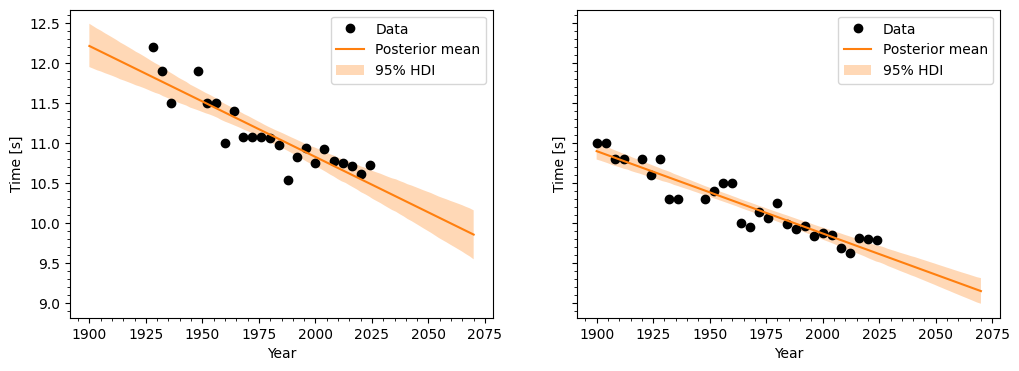

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

x_range = np.linspace(1900, 2070, 100) # Predict across a range of x values from 1 to 11
new_data = pd.DataFrame({"x": x_range}) #dataframe with the new x-values
model.predict(idata, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Compute posterior mean and HDI at each x point
posterior_mean = y_mean_draws.mean(axis=0)
hdi = az.hdi(y_mean_draws, hdi_prob=0.95)

# Plot the results
axes[0].plot(W_year, W_time, 'ok', label="Data")
axes[0].plot(x_range, posterior_mean, color="C1", label="Posterior mean")
axes[0].fill_between(
    x_range,
    hdi[:, 0],
    hdi[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Time [s]')
axes[0].legend()
axes[0].minorticks_on()

#WOMEN'S ENDS HERE ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^ WOMENS ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

x_rangeM = np.linspace(1900, 2070, 100) # Predict across a range of x values from 1 to 11
new_dataM = pd.DataFrame({"x": x_rangeM}) #dataframe with the new x-values
modelM.predict(idataM, data=new_dataM, kind='response_params') #predict the distribution of regression lines at each x-value

# Make random draws from the posterior of the regression lines
y_mean_drawsM = idataM.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_drawsM = y_mean_drawsM.reshape(-1, len(x_rangeM))

# Compute posterior mean and HDI at each x point
posterior_meanM = y_mean_drawsM.mean(axis=0)
hdi = az.hdi(y_mean_drawsM, hdi_prob=0.95)

# Plot the results
axes[1].plot(M_year, M_time, 'ok', label="Data")
axes[1].plot(x_rangeM, posterior_meanM, color="C1", label="Posterior mean")
axes[1].fill_between(
    x_rangeM,
    hdi[:, 0],
    hdi[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Time [s]')
axes[1].legend()
axes[1].minorticks_on()

/tmp/ipykernel_59563/2866002383.py:17: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(y_mean_drawsM, hdi_prob=0.95)


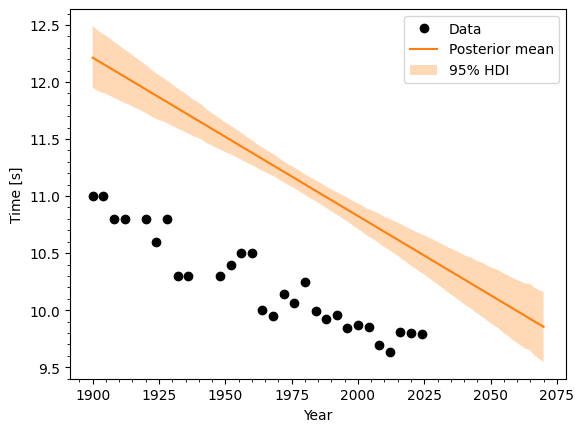

In [32]:
dataM = pd.DataFrame({"x": M_year, "y": M_time}) #put the data into a dataframe with variable names "x" and "y".
modelM = bmb.Model("y ~ x", dataM) #setup the first-order polynomial model
idataM = model.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sample the posteriors

x_rangeM = np.linspace(1900, 2070, 100) # Predict across a range of x values from 1 to 11
new_dataM = pd.DataFrame({"x": x_rangeM}) #dataframe with the new x-values
modelM.predict(idataM, data=new_dataM, kind='response_params') #predict the distribution of regression lines at each x-value

# Make random draws from the posterior of the regression lines
y_mean_drawsM = idataM.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_drawsM = y_mean_drawsM.reshape(-1, len(x_rangeM))

# Compute posterior mean and HDI at each x point
posterior_meanM = y_mean_drawsM.mean(axis=0)
hdi = az.hdi(y_mean_drawsM, hdi_prob=0.95)

# Plot the results
plt.plot(M_year, M_time, 'ok', label="Data")
plt.plot(x_rangeM, posterior_meanM, color="C1", label="Posterior mean")
plt.fill_between(
    x_rangeM,
    hdi[:, 0],
    hdi[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
)
plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.legend()
plt.minorticks_on()

In [18]:
# Create prediction ranges
x_range = np.linspace(1900, 2050, 100)
M_range = np.linspace(1900, 2050, 100)

new_data = pd.DataFrame({"x": x_range})
newM_data = pd.DataFrame({"M": M_range})

# Generate predictions (IMPORTANT: store outputs)
idata_pred_x = model.predict(idata, data=new_data, kind='response_params')
idata_pred_M = model.predict(idata, data=newM_data, kind='response_params')

# Extract posterior draws
y_mean_draws_x = idata_pred_x.posterior["mu"].values
y_mean_draws_M = idata_pred_M.posterior["mu"].values

# Reshape to (draws, points)
y_mean_draws_x = y_mean_draws_x.reshape(-1, len(x_range))
y_mean_draws_M = y_mean_draws_M.reshape(-1, len(M_range))

# Compute summaries
posterior_mean_x = y_mean_draws_x.mean(axis=0)
hdi_x = az.hdi(y_mean_draws_x, hdi_prob=0.95)

posterior_mean_M = y_mean_draws_M.mean(axis=0)
hdi_M = az.hdi(y_mean_draws_M, hdi_prob=0.95)

# Plot
plt.plot(W_year, W_time, 'ok', label="W data")
plt.plot(x_range, posterior_mean_x, color="C1", label="W mean")
plt.fill_between(
    x_range,
    hdi_x[:, 0],
    hdi_x[:, 1],
    alpha=0.3,
    color="C1",
    edgecolor=None
)

plt.plot(M_year, M_time, 'o', color="C2", label="M data")
plt.plot(M_range, posterior_mean_M, color="C2", label="M mean")
plt.fill_between(
    M_range,
    hdi_M[:, 0],
    hdi_M[:, 1],
    alpha=0.3,
    color="C2",
    edgecolor=None
)

plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.legend()
plt.minorticks_on()

KeyError: 'x'

/tmp/ipykernel_59563/278101002.py:15: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_women = az.hdi(y_mean_draws_women, hdi_prob=0.95)
/tmp/ipykernel_59563/278101002.py:28: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_men = az.hdi(y_mean_draws_men, hdi_prob=0.95) # Fix 5: Use y_mean_draws_men


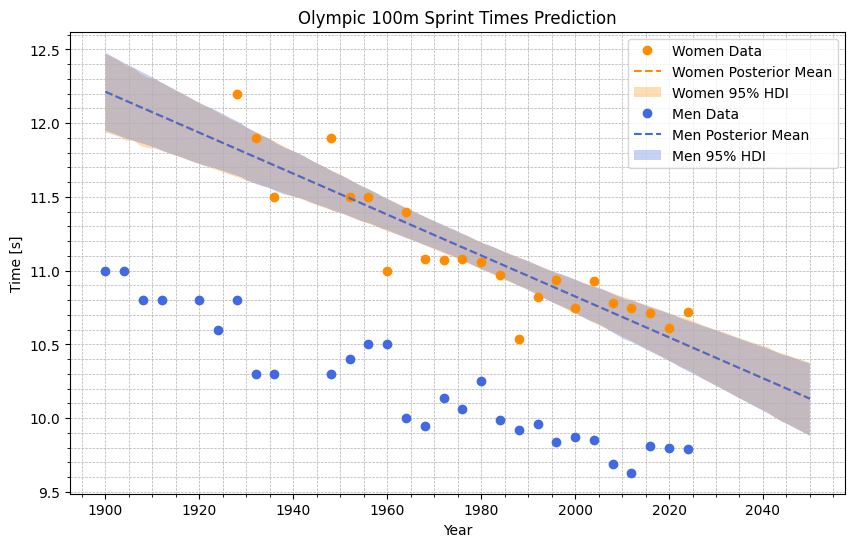

In [17]:
x_range = np.linspace(1900, 2050, 100) # Common range for predictions

# Create new dataframes for prediction for both women and men, ensuring 'x' is the column name
new_data_women = pd.DataFrame({"x": x_range})
new_data_men = pd.DataFrame({"x": x_range}) # Fix 1: Renamed column from 'M' to 'x'

# Perform predictions for women's data
# `model` and `idata` are for women (from previous cell)
model.predict(idata, data=new_data_women, kind='response_params')
y_mean_draws_women = idata.posterior["mu"].values
y_mean_draws_women = y_mean_draws_women.reshape(-1, len(x_range))

# Compute posterior mean and HDI for women
posterior_mean_women = y_mean_draws_women.mean(axis=0)
hdi_women = az.hdi(y_mean_draws_women, hdi_prob=0.95)

# Perform predictions for men's data
# IMPORTANT: There is a logical error in the preceding cell (EWtaDuXG8lcO) where `modelM`
# was incorrectly trained using `data` (women's data) instead of `dataM` (men's data).
# For this cell to function correctly, `modelM` and `idataM` must represent the men's model.
# Assuming `modelM` and `idataM` are correctly trained on men's data:
modelM.predict(idataM, data=new_data_men, kind='response_params') # Fix 2: Use modelM and idataM for men
y_mean_draws_men = idataM.posterior["mu"].values # Fix 3: Use idataM for men's draws
y_mean_draws_men = y_mean_draws_men.reshape(-1, len(x_range))

# Compute posterior mean and HDI for men
posterior_mean_men = y_mean_draws_men.mean(axis=0) # Fix 4: Use y_mean_draws_men
hdi_men = az.hdi(y_mean_draws_men, hdi_prob=0.95) # Fix 5: Use y_mean_draws_men

# Plot the results for both women and men
plt.figure(figsize=(10, 6))

# Plot for women
plt.plot(W_year, W_time, 'o', color='darkorange', label="Women Data")
plt.plot(x_range, posterior_mean_women, color="darkorange", linestyle='--', label="Women Posterior Mean")
plt.fill_between(
    x_range,
    hdi_women[:, 0],
    hdi_women[:, 1],
    alpha=0.3,
    color="darkorange",
    label="Women 95% HDI",
    edgecolor = None
)

# Plot for men
plt.plot(M_year, M_time, 'o', color='royalblue', label="Men Data")
plt.plot(x_range, posterior_mean_men, color="royalblue", linestyle='--', label="Men Posterior Mean") # Fix 6: Use men's posterior mean and distinct color
plt.fill_between(
    x_range,
    hdi_men[:, 0], # Fix 7: Use men's HDI
    hdi_men[:, 1], # Fix 7: Use men's HDI
    alpha=0.3,
    color="royalblue", # Fix 8: Use distinct color
    label="Men 95% HDI",
    edgecolor = None
)
plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.title('Olympic 100m Sprint Times Prediction')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()